<a href="https://colab.research.google.com/github/arafatro/IntroToDS/blob/main/Practice%20Materials/Week%204/DS_Practice_Bivariate_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/arafatro/IntroToDS/blob/main/Practice%20Materials/Week%204/DS_Practice_Bivariate_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Data Science
## Practice Session — Bivariate Analysis: Scatter Plots, Correlation, and Causation
**Eötvös Loránd University (ELTE) · Faculty of Informatics**

---
**Instructor:** Arafat Md Easin  
**Goal:** By the end of this session you will be able to:
- Understand what bivariate analysis is and when to use it
- Produce and read scatter plots for pairs of variables
- Compute and interpret Pearson and Spearman correlation coefficients
- Explain why correlation does not imply causation
- Detect and handle nonlinear relationships
- Choose the right plot and statistic for any variable pair

> **Tip:** Run each cell with `Shift + Enter` and read the comments carefully before moving on.

---
## Part 0 — Setup & Dataset

In [1]:
!pip install ucimlrepo -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from ucimlrepo import fetch_ucirepo

# Style settings — applied once for the whole notebook
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Load dataset
student_performance = fetch_ucirepo(id=320)
X = student_performance.data.features
y = student_performance.data.targets
df = pd.concat([X, y], axis=1)

print("Dataset loaded:", df.shape)
df.head(3)

Dataset loaded: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12


---
## Part 1 — What is Bivariate Analysis?

In univariate analysis we study **one variable at a time**.  
In **bivariate analysis** we study the **relationship between two variables**.

The right tool depends on the types of both variables:

| Variable X | Variable Y | Tool |
|---|---|---|
| Numerical | Numerical | Scatter plot, Correlation |
| Categorical | Numerical | Box plot by group, Bar chart of means |
| Categorical | Categorical | Contingency table, Stacked bar chart |

Key questions bivariate analysis answers:
- Do two variables **move together**? (correlation)
- Is the relationship **linear or nonlinear**?
- Is there a **direction** — positive or negative?
- How **strong** is the association?

In [3]:
# ── 1.1  Quick overview of variable pairs we will explore ─────────────

pairs = pd.DataFrame({
    "X": ["studytime", "absences", "Medu", "failures", "G1"],
    "Y": ["G3", "G3", "G3", "G3", "G3"],
    "X Type": ["Numerical", "Numerical", "Numerical", "Numerical", "Numerical"],
    "Expected relationship": [
        "Positive — more study, higher grade",
        "Negative — more absences, lower grade",
        "Positive — better educated mother, higher grade",
        "Negative — more failures, lower grade",
        "Strong positive — mid-term predicts final"
    ]
})
display(pairs)

,X,Y,X Type,Expected relationship
0,studytime,G3,Numerical,"Positive — more study, higher grade"
1,absences,G3,Numerical,"Negative — more absences, lower grade"
2,Medu,G3,Numerical,"Positive — better educated mother, higher grade"
3,failures,G3,Numerical,"Negative — more failures, lower grade"
4,G1,G3,Numerical,Strong positive — mid-term predicts final


---
## Part 2 — Scatter Plots: Numerical vs Numerical

A **scatter plot** places each observation as a point at coordinates (X, Y).  
It reveals:
- **Direction**: positive (↗), negative (↘), or none
- **Form**: linear, curved, or no pattern
- **Strength**: tight cloud = strong, loose cloud = weak
- **Outliers**: points far from the main cluster

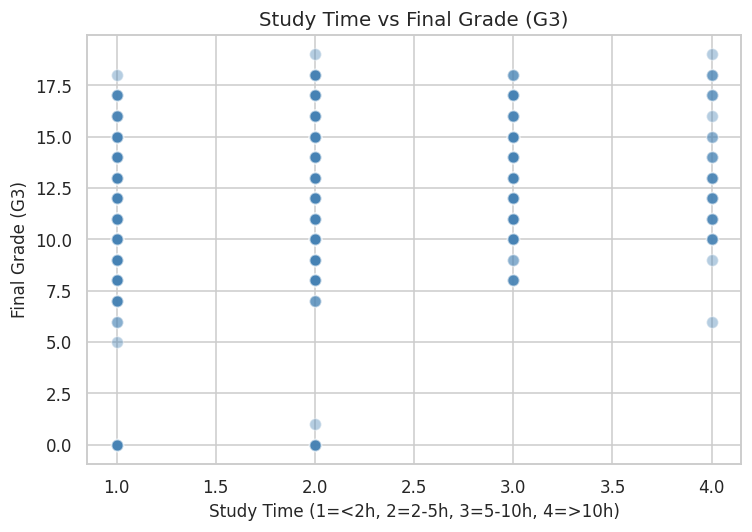

Observation: a slight upward trend — more study time tends to give higher grades.
But there is a lot of scatter — other factors matter too.


In [4]:
# ── 2.1  A basic scatter plot ─────────────────────────────────────────
# Does studying more lead to a higher final grade?

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df["studytime"], df["G3"],
           alpha=0.4, color="steelblue", edgecolors="white", s=60)
ax.set_title("Study Time vs Final Grade (G3)")
ax.set_xlabel("Study Time (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)")
ax.set_ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()

print("Observation: a slight upward trend — more study time tends to give higher grades.")
print("But there is a lot of scatter — other factors matter too.")

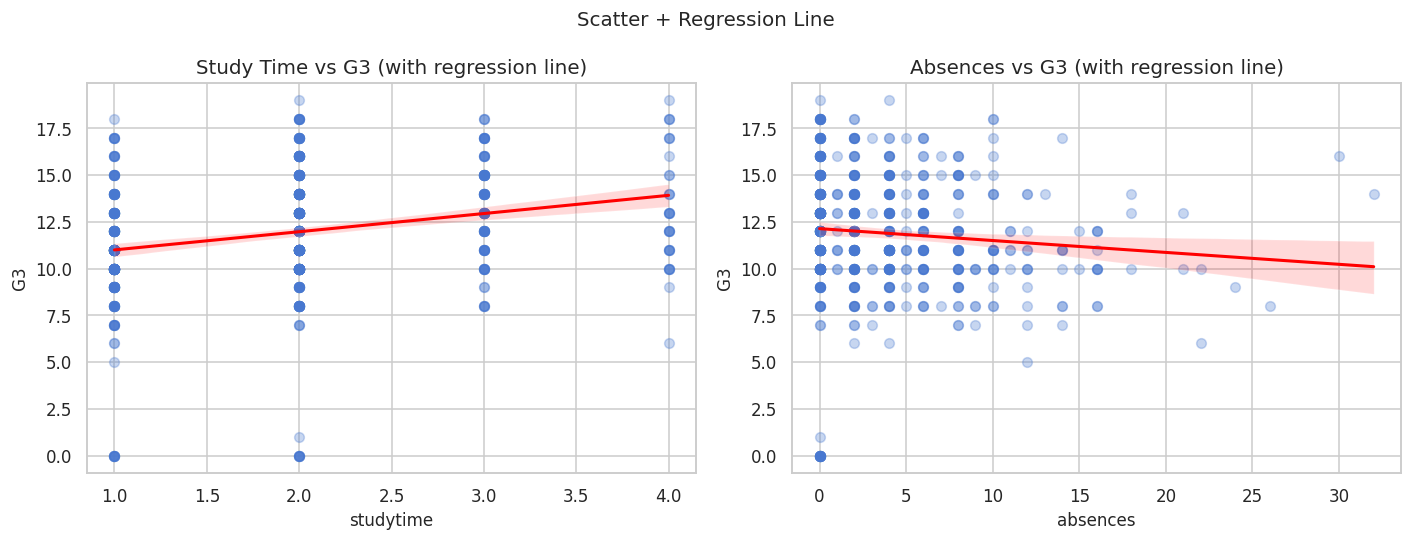

Shaded band = 95% confidence interval around the fitted line.
Wide band = less certainty in the slope estimate.


In [5]:
# ── 2.2  Adding a regression line — is there a linear trend? ─────────
# sns.regplot draws the scatter + OLS regression line + confidence band.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.regplot(data=df, x="studytime", y="G3",
            scatter_kws={"alpha": 0.3, "s": 40},
            line_kws={"color": "red", "linewidth": 2},
            ax=axes[0])
axes[0].set_title("Study Time vs G3 (with regression line)")

sns.regplot(data=df, x="absences", y="G3",
            scatter_kws={"alpha": 0.3, "s": 40},
            line_kws={"color": "red", "linewidth": 2},
            ax=axes[1])
axes[1].set_title("Absences vs G3 (with regression line)")

plt.suptitle("Scatter + Regression Line", fontsize=13)
plt.tight_layout()
plt.show()

print("Shaded band = 95% confidence interval around the fitted line.")
print("Wide band = less certainty in the slope estimate.")

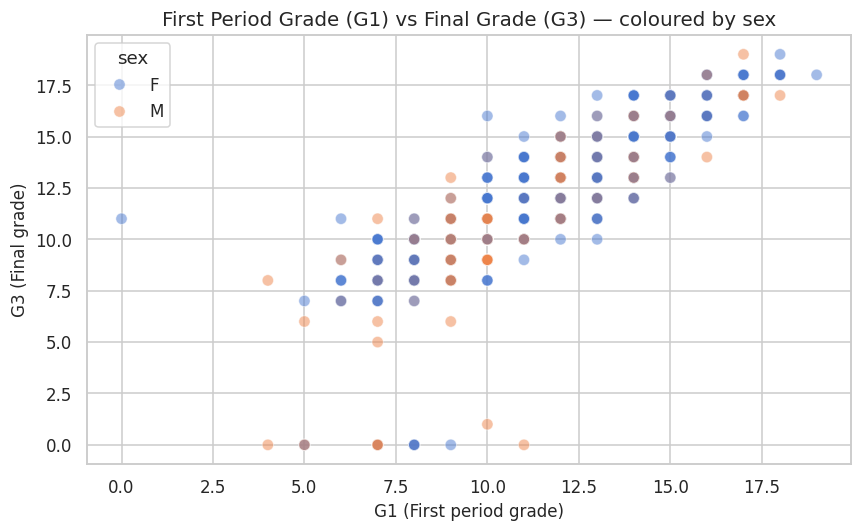

G1 and G3 are strongly correlated — students who start well tend to finish well.


In [6]:
# ── 2.3  Adding a third variable with colour ──────────────────────────
# Colour encodes a third variable, turning bivariate into multivariate.

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(data=df, x="G1", y="G3",
                hue="sex",
                alpha=0.5, s=55, ax=ax)
ax.set_title("First Period Grade (G1) vs Final Grade (G3) — coloured by sex")
ax.set_xlabel("G1 (First period grade)")
ax.set_ylabel("G3 (Final grade)")
plt.tight_layout()
plt.show()

print("G1 and G3 are strongly correlated — students who start well tend to finish well.")

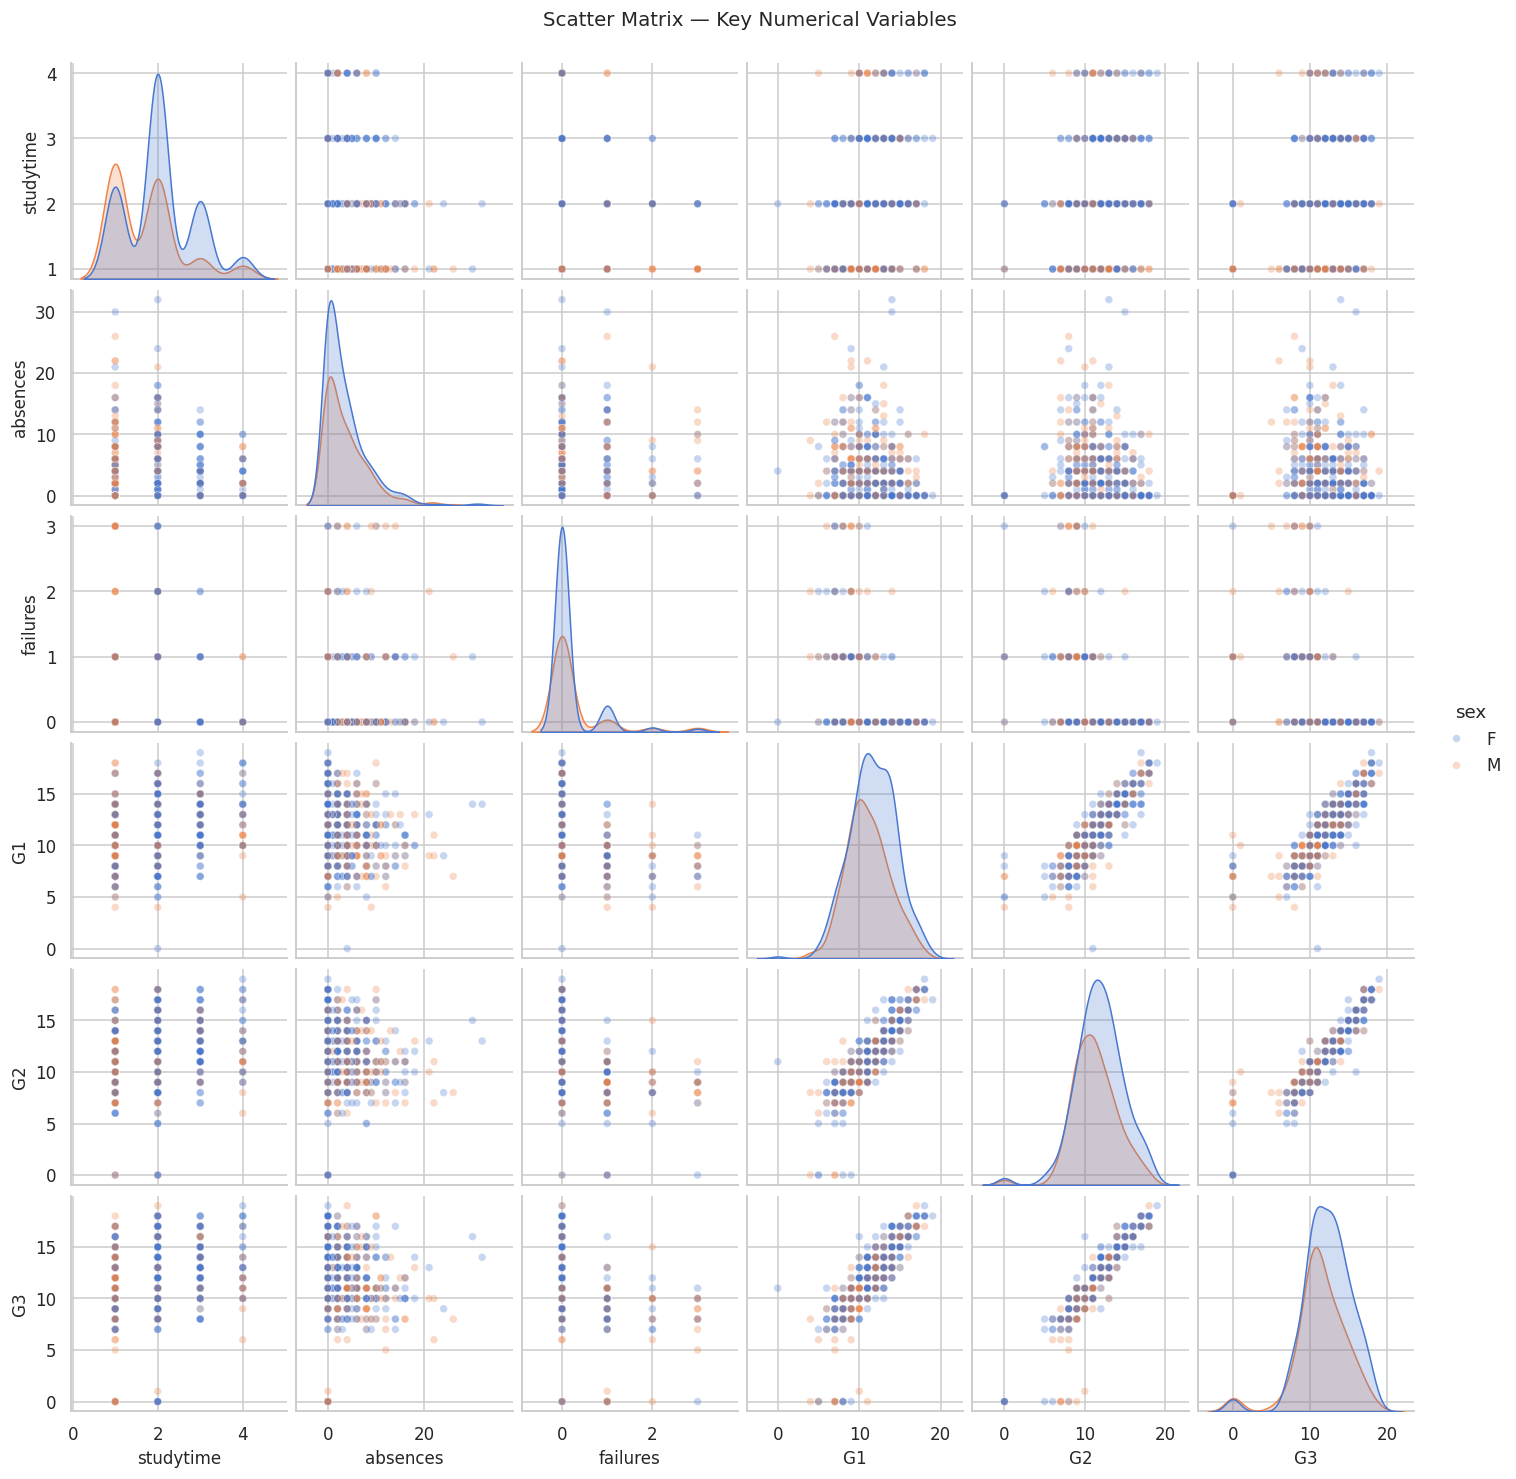

The G1-G2-G3 block shows the tightest linear cluster — high inter-period correlation.
absences and failures show wide scatter with G3 — weaker relationships.


In [7]:
# ── 2.4  Scatter matrix — all pairs at once ───────────────────────────
# A pairplot draws scatter plots for every pair of selected columns.
# Diagonal = univariate KDE of each variable.

cols_of_interest = ["studytime", "absences", "failures", "G1", "G2", "G3"]

pair_grid = sns.pairplot(
    df[cols_of_interest + ["sex"]],
    hue="sex",
    diag_kind="kde",
    plot_kws={"alpha": 0.3, "s": 25},
    height=2.2
)
pair_grid.figure.suptitle("Scatter Matrix — Key Numerical Variables",
                           y=1.02, fontsize=13)
plt.show()

print("The G1-G2-G3 block shows the tightest linear cluster — high inter-period correlation.")
print("absences and failures show wide scatter with G3 — weaker relationships.")

### Exercise 1
1. Create a scatter plot of `Medu` (mother's education) vs `G3`.
2. Add a regression line using `sns.regplot`.
3. Does the plot suggest a positive or negative relationship? Is it strong or weak?
```python
# Your code here
```

In [ ]:
# Your answer here


---
## Part 3 — Correlation Coefficients

A correlation coefficient **quantifies** what the scatter plot shows visually.

### Pearson r
Measures the strength and direction of a **linear** relationship.

$$
r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}
         {\sqrt{\sum(x_i-\bar{x})^2} \cdot \sqrt{\sum(y_i-\bar{y})^2}}
\quad \in [-1, 1]
$$

| Value | Interpretation |
|---|---|
| +1.0 | Perfect positive linear relationship |
| +0.7 to +0.9 | Strong positive |
| +0.4 to +0.7 | Moderate positive |
| 0 to ±0.3 | Weak or no linear relationship |
| −0.4 to −0.7 | Moderate negative |
| −1.0 | Perfect negative linear relationship |

### Spearman ρ
Measures the strength of a **monotonic** relationship (ranks, not values).  
Use when data is ordinal, skewed, or the relationship is nonlinear but monotonic.

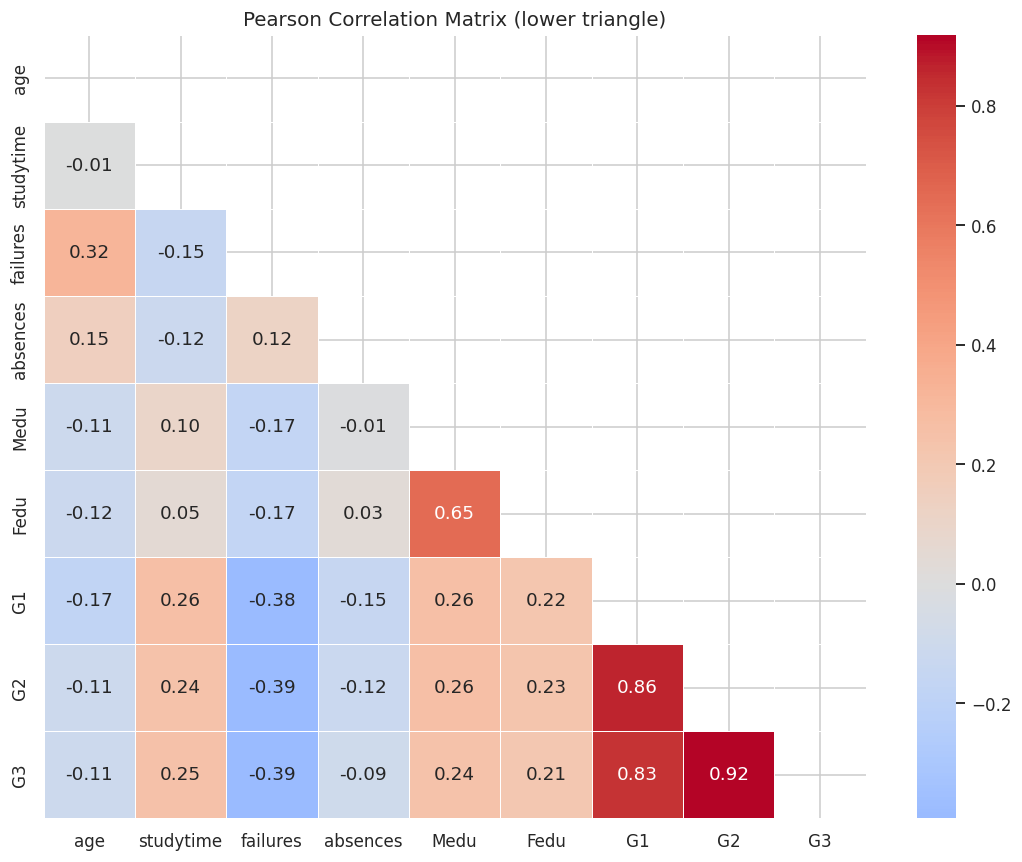

Strong positives (red): G1-G2-G3 block
Strong negative (blue): failures vs G3


In [8]:
# ── 3.1  Pearson correlation — the full matrix ────────────────────────

num_cols = ["age", "studytime", "failures", "absences",
            "Medu", "Fedu", "G1", "G2", "G3"]

corr_pearson = df[num_cols].corr(method="pearson").round(3)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr_pearson,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5,
    mask=mask,
    ax=ax
)
ax.set_title("Pearson Correlation Matrix (lower triangle)")
plt.tight_layout()
plt.show()

print("Strong positives (red): G1-G2-G3 block")
print("Strong negative (blue): failures vs G3")

In [9]:
# ── 3.2  Pearson vs Spearman — when do they differ? ───────────────────

pairs_to_compare = [
    ("G1", "G3"),
    ("absences", "G3"),
    ("failures", "G3"),
    ("studytime", "G3"),
    ("Medu", "G3")
]

results = []
for x, y in pairs_to_compare:
    r_p, p_p = stats.pearsonr(df[x].dropna(), df[y].dropna())
    r_s, p_s = stats.spearmanr(df[x].dropna(), df[y].dropna())
    results.append({
        "X": x, "Y": y,
        "Pearson r": round(r_p, 3), "Pearson p": round(p_p, 4),
        "Spearman ρ": round(r_s, 3), "Spearman p": round(p_s, 4)
    })

corr_compare = pd.DataFrame(results)
display(corr_compare)

print()
print("When Pearson ≈ Spearman  → relationship is roughly linear")
print("When they differ notably → relationship may be nonlinear or data is skewed")

,X,Y,Pearson r,Pearson p,Spearman ρ,Spearman p
0,G1,G3,0.826,0.0000,0.883,0.0
1,absences,G3,-0.091,0.0199,-0.159,0.0
2,failures,G3,-0.393,0.0000,-0.448,0.0
3,studytime,G3,0.250,0.0000,0.275,0.0
4,Medu,G3,0.240,0.0000,0.284,0.0



When Pearson ≈ Spearman  → relationship is roughly linear
When they differ notably → relationship may be nonlinear or data is skewed


In [10]:
# ── 3.3  Statistical significance of correlation ──────────────────────
# A correlation is only meaningful if it is statistically significant.
# p-value < 0.05 → we reject the null hypothesis of zero correlation.

print("Correlation of all numerical columns with G3:\n")
sig_results = []
for col in num_cols:
    if col == "G3":
        continue
    r, p = stats.pearsonr(df[col].dropna(), df["G3"].dropna())
    sig_results.append({
        "Feature": col,
        "Pearson r": round(r, 3),
        "p-value": round(p, 4),
        "Significant?": "Yes" if p < 0.05 else "No"
    })

sig_df = pd.DataFrame(sig_results).sort_values("Pearson r", key=abs, ascending=False)
display(sig_df)
print()
print("Note: age has a very small |r| and p > 0.05 → not significant.")

Correlation of all numerical columns with G3:



,Feature,Pearson r,p-value,Significant?
7,G2,0.919,0.0000,Yes
6,G1,0.826,0.0000,Yes
2,failures,-0.393,0.0000,Yes
1,studytime,0.250,0.0000,Yes
4,Medu,0.240,0.0000,Yes
5,Fedu,0.212,0.0000,Yes
0,age,-0.107,0.0066,Yes
3,absences,-0.091,0.0199,Yes



Note: age has a very small |r| and p > 0.05 → not significant.


### Exercise 2
1. Compute Pearson and Spearman correlation between `goout` (going out with friends) and `G3`.
2. Print both values. Which is larger in absolute terms?
3. Is the correlation statistically significant (p < 0.05)?
4. Write one sentence interpreting the result.
```python
# Your code here
```

In [ ]:
# Your answer here


---
## Part 4 — Correlation ≠ Causation

This is one of the most important principles in data science.

> **Just because two variables are correlated does not mean one causes the other.**

There are three possible explanations for a correlation between X and Y:

```
1. X causes Y              X → Y
2. Y causes X              Y → X
3. A third variable Z      Z → X
   (confounder) causes both         Z → Y
```

Famous spurious examples:
- Ice cream sales correlate with drowning deaths → both caused by **summer heat** (Z)
- Shoe size correlates with reading ability in children → both caused by **age** (Z)
- Nicolas Cage films per year correlates with pool drownings → pure coincidence

In [11]:
# ── 4.1  A real confounded relationship in our data ───────────────────
# Medu (mother's education) correlates with G3.
# But is it Medu → G3 directly, or is there a confounder?
# Possibility: higher Medu → more studytime → higher G3

r_medu_g3, _   = stats.pearsonr(df["Medu"], df["G3"])
r_medu_st, _   = stats.pearsonr(df["Medu"], df["studytime"])
r_st_g3, _     = stats.pearsonr(df["studytime"], df["G3"])

print("Checking a possible confounded path:")
print(f"  Medu  → G3        : r = {r_medu_g3:.3f}")
print(f"  Medu  → studytime : r = {r_medu_st:.3f}")
print(f"  studytime → G3    : r = {r_st_g3:.3f}")
print()
print("Interpretation:")
print("  Higher Medu correlates with more study time.")
print("  More study time correlates with higher G3.")
print("  → studytime may partially mediate the Medu–G3 relationship.")
print("  We cannot conclude Medu directly causes higher G3.")

Checking a possible confounded path:
  Medu  → G3        : r = 0.240
  Medu  → studytime : r = 0.097
  studytime → G3    : r = 0.250

Interpretation:
  Higher Medu correlates with more study time.
  More study time correlates with higher G3.
  → studytime may partially mediate the Medu–G3 relationship.
  We cannot conclude Medu directly causes higher G3.


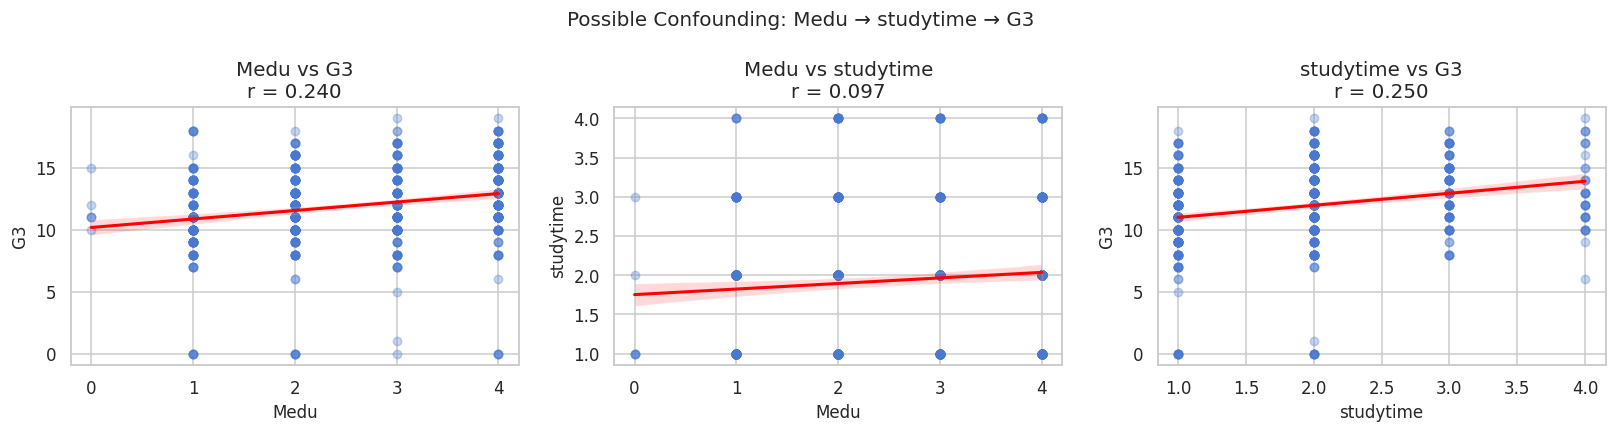

In [12]:
# ── 4.2  Visualise the confounding path ───────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs_conf = [
    ("Medu", "G3",       f"r = {r_medu_g3:.3f}"),
    ("Medu", "studytime",f"r = {r_medu_st:.3f}"),
    ("studytime", "G3",  f"r = {r_st_g3:.3f}")
]

for ax, (x, y, label) in zip(axes, pairs_conf):
    sns.regplot(data=df, x=x, y=y,
                scatter_kws={"alpha": 0.3, "s": 30},
                line_kws={"color": "red", "linewidth": 2},
                ax=ax)
    ax.set_title(f"{x} vs {y}\n{label}")

plt.suptitle("Possible Confounding: Medu → studytime → G3", fontsize=13)
plt.tight_layout()
plt.show()

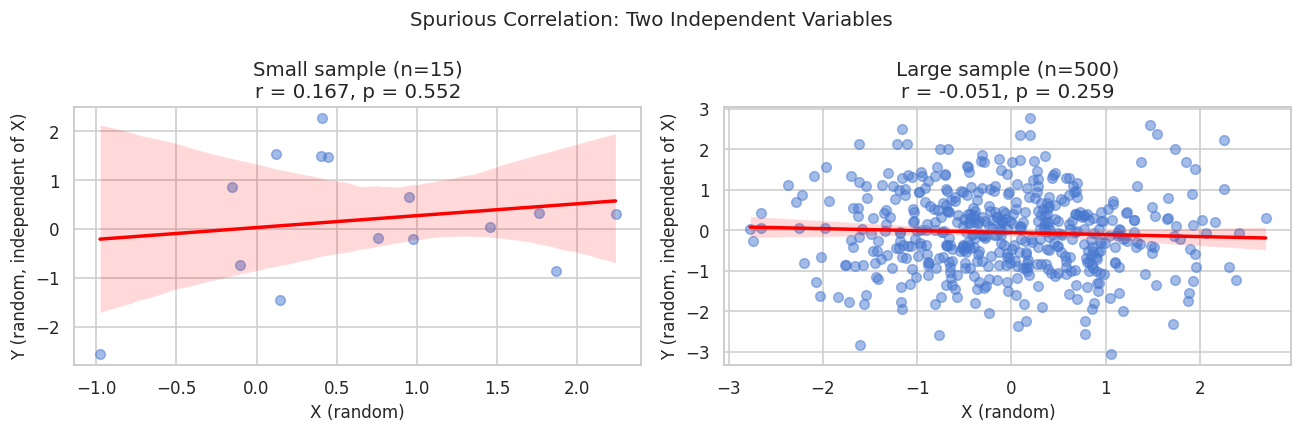

Small sample: r = 0.167, p = 0.552  → may look correlated by chance
Large sample: r = -0.051, p = 0.259  → true zero relationship revealed

Lesson: Never trust a correlation from a small sample.


In [13]:
# ── 4.3  Spurious correlation — a simulated example ───────────────────
# We generate two completely independent random variables.
# In a small sample, they can appear correlated by chance.

np.random.seed(0)
n_small  = 15
n_large  = 500

x_small  = np.random.normal(0, 1, n_small)
y_small  = np.random.normal(0, 1, n_small)
x_large  = np.random.normal(0, 1, n_large)
y_large  = np.random.normal(0, 1, n_large)

r_small, p_small = stats.pearsonr(x_small, y_small)
r_large, p_large = stats.pearsonr(x_large, y_large)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, x, y, r, p, n, title in [
    (axes[0], x_small, y_small, r_small, p_small, n_small, f"Small sample (n={n_small})"),
    (axes[1], x_large, y_large, r_large, p_large, n_large, f"Large sample (n={n_large})")
]:
    sns.regplot(x=x, y=y,
                scatter_kws={"alpha": 0.5, "s": 40},
                line_kws={"color": "red"},
                ax=ax)
    ax.set_title(f"{title}\nr = {r:.3f}, p = {p:.3f}")
    ax.set_xlabel("X (random)")
    ax.set_ylabel("Y (random, independent of X)")

plt.suptitle("Spurious Correlation: Two Independent Variables", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Small sample: r = {r_small:.3f}, p = {p_small:.3f}  → may look correlated by chance")
print(f"Large sample: r = {r_large:.3f}, p = {p_large:.3f}  → true zero relationship revealed")
print()
print("Lesson: Never trust a correlation from a small sample.")

### Exercise 3
Look at the correlation between `Walc` (weekend alcohol consumption) and `G3`.
1. Compute Pearson r and its p-value.
2. Plot a scatter plot with regression line.
3. Could there be a confounder? Name at least one possible third variable.
4. Does correlation here imply that reducing alcohol consumption would raise grades? Explain.
```python
# Your code here
```

In [ ]:
# Your answer here


---
## Part 5 — Nonlinearity

Pearson r only captures **linear** relationships.  
If the relationship is curved, r can be close to zero even when a strong pattern exists.

```
Linear:      Y ∝ X          Pearson r works well
Monotonic:   Y always ↑ as X ↑ (but not straight)  Spearman ρ works better
Non-monotonic: U-shape, inverted-U    Neither r nor ρ works — visualise first!
```

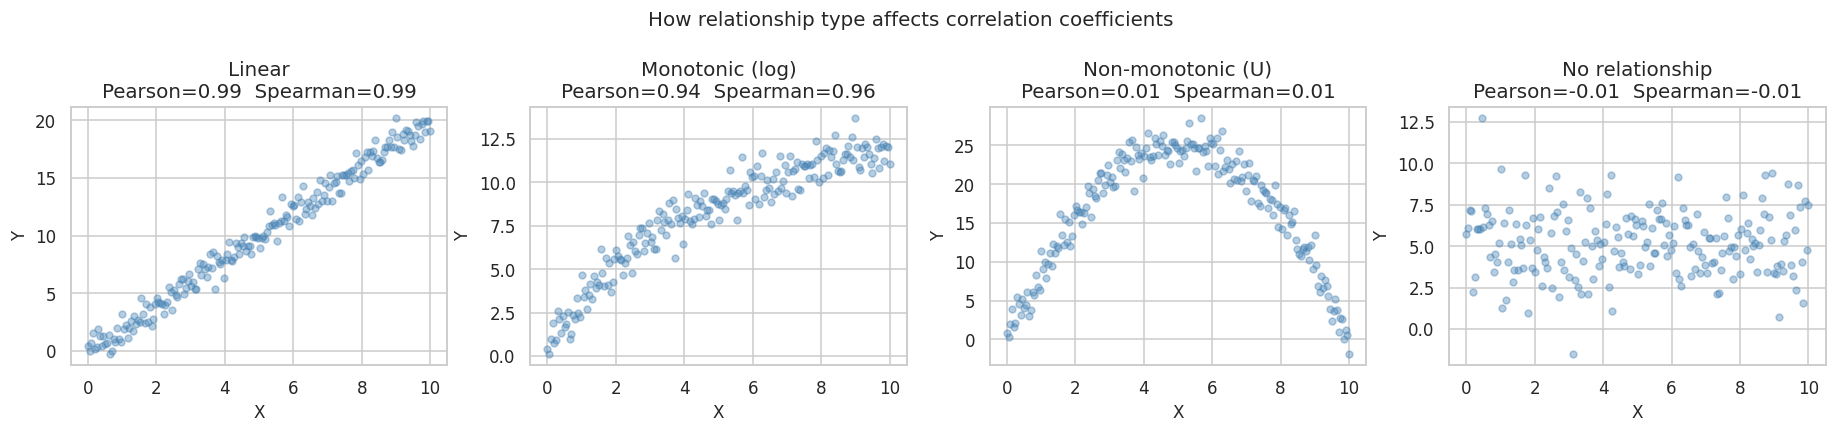

Key: For the non-monotonic (U-shape), both r and ρ ≈ 0 despite a clear pattern.
     Always plot before computing correlation!


In [14]:
# ── 5.1  Illustrating linear, monotonic, and nonlinear ────────────────

np.random.seed(42)
x = np.linspace(0, 10, 200)
noise = np.random.normal(0, 0.8, 200)

y_linear     = 2 * x + noise
y_monotonic  = np.log1p(x) * 5 + noise
y_nonmonotonic = -(x - 5)**2 + 25 + noise * 2   # inverted U
y_none       = np.random.normal(5, 2, 200)        # no relationship

scenarios = [
    (x, y_linear,        "Linear"),
    (x, y_monotonic,     "Monotonic (log)"),
    (x, y_nonmonotonic,  "Non-monotonic (U)"),
    (x, y_none,          "No relationship")
]

fig, axes = plt.subplots(1, 4, figsize=(17, 4))

for ax, (xi, yi, title) in zip(axes, scenarios):
    r_p, _ = stats.pearsonr(xi, yi)
    r_s, _ = stats.spearmanr(xi, yi)
    ax.scatter(xi, yi, alpha=0.4, s=20, color="steelblue")
    ax.set_title(f"{title}\nPearson={r_p:.2f}  Spearman={r_s:.2f}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

plt.suptitle("How relationship type affects correlation coefficients", fontsize=13)
plt.tight_layout()
plt.show()

print("Key: For the non-monotonic (U-shape), both r and ρ ≈ 0 despite a clear pattern.")
print("     Always plot before computing correlation!")

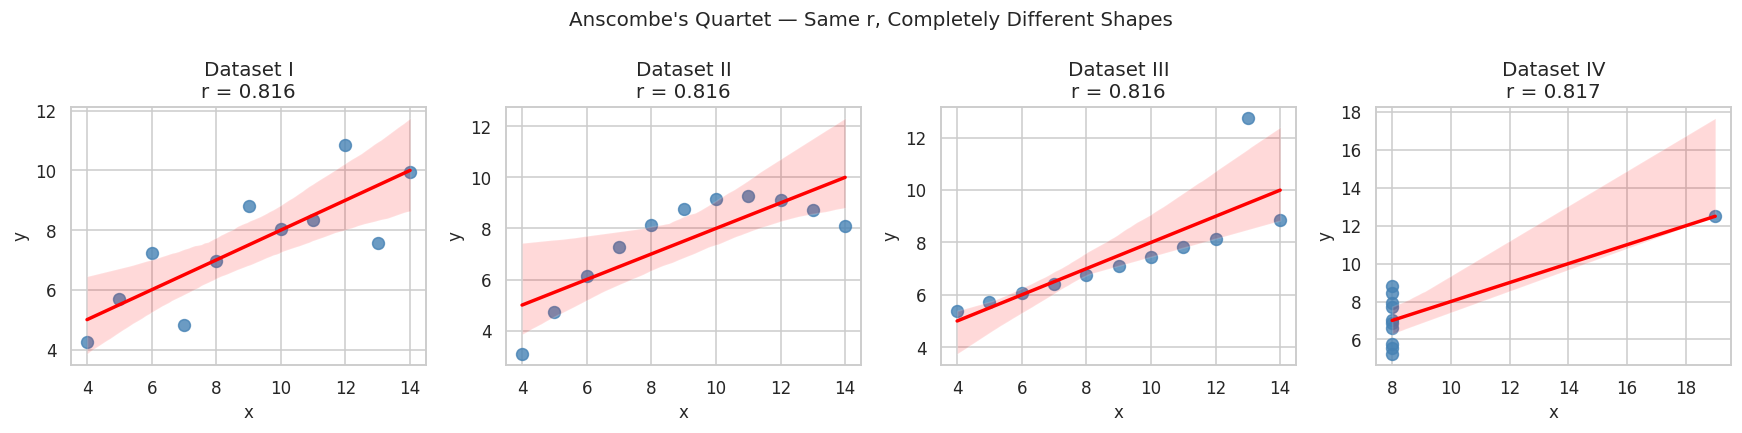

All four datasets have: mean(x)=9, mean(y)≈7.5, r≈0.816, same regression line.
But datasets II, III, IV clearly violate the linear assumption.
Lesson: a single number (r) can never replace a plot.


In [15]:
# ── 5.2  Anscombe's Quartet — why visualisation always comes first ─────
# Anscombe (1973) constructed 4 datasets with IDENTICAL statistics
# but completely different shapes.

anscombe = sns.load_dataset("anscombe")

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

for ax, (dataset, group) in zip(axes, anscombe.groupby("dataset")):
    r, _ = stats.pearsonr(group["x"], group["y"])
    sns.regplot(data=group, x="x", y="y",
                scatter_kws={"s": 60, "color": "steelblue"},
                line_kws={"color": "red"},
                ax=ax)
    ax.set_title(f"Dataset {dataset}\nr = {r:.3f}")

plt.suptitle("Anscombe's Quartet — Same r, Completely Different Shapes",
             fontsize=13)
plt.tight_layout()
plt.show()

print("All four datasets have: mean(x)=9, mean(y)≈7.5, r≈0.816, same regression line.")
print("But datasets II, III, IV clearly violate the linear assumption.")
print("Lesson: a single number (r) can never replace a plot.")

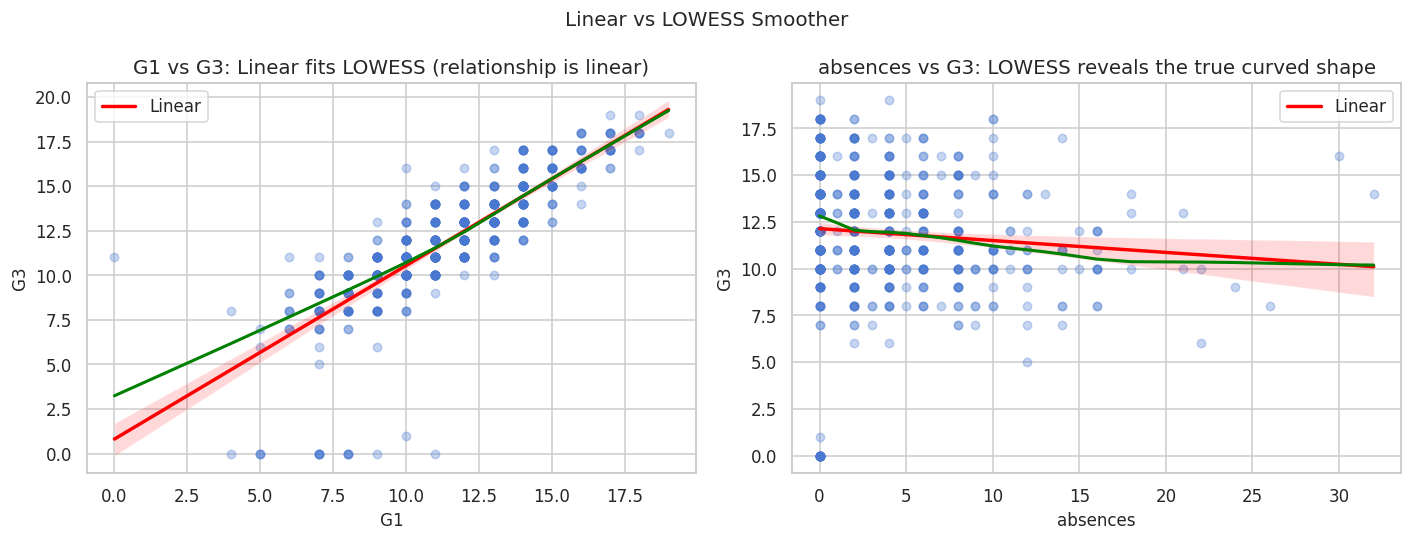

When red ≠ green, the linear model is not a good fit — consider transformation or nonlinear model.


In [16]:
# ── 5.3  Detecting nonlinearity with a lowess smoother ────────────────
# LOWESS (locally weighted scatterplot smoothing) draws a flexible
# curve through the data without assuming linearity.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Linear fit vs LOWESS for G1 vs G3
sns.regplot(data=df, x="G1", y="G3",
            scatter_kws={"alpha": 0.3, "s": 30},
            line_kws={"color": "red", "label": "Linear"},
            ax=axes[0])
sns.regplot(data=df, x="G1", y="G3",
            scatter=False, lowess=True,
            line_kws={"color": "green", "linewidth": 2, "label": "LOWESS"},
            ax=axes[0])
axes[0].legend()
axes[0].set_title("G1 vs G3: Linear fits LOWESS (relationship is linear)")

# Linear fit vs LOWESS for absences vs G3
sns.regplot(data=df, x="absences", y="G3",
            scatter_kws={"alpha": 0.3, "s": 30},
            line_kws={"color": "red", "label": "Linear"},
            ax=axes[1])
sns.regplot(data=df, x="absences", y="G3",
            scatter=False, lowess=True,
            line_kws={"color": "green", "linewidth": 2, "label": "LOWESS"},
            ax=axes[1])
axes[1].legend()
axes[1].set_title("absences vs G3: LOWESS reveals the true curved shape")

plt.suptitle("Linear vs LOWESS Smoother", fontsize=13)
plt.tight_layout()
plt.show()

print("When red ≠ green, the linear model is not a good fit — consider transformation or nonlinear model.")

### Exercise 4
1. Create a scatter plot of `failures` vs `G3` with both a linear regression line and a LOWESS smoother.
2. Does the relationship appear linear or nonlinear?
3. Compute Pearson r and Spearman ρ. Which coefficient is more appropriate here, and why?
```python
# Your code here
```

In [ ]:
# Your answer here


---
## Part 6 — Categorical vs Numerical: Group Comparisons

When one variable is categorical and the other is numerical, we compare the **distribution of the numerical variable across groups**.

/tmp/ipykernel_635/410709649.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cat, y="G3", ax=ax,
/tmp/ipykernel_635/410709649.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cat, y="G3", ax=ax,
/tmp/ipykernel_635/410709649.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cat, y="G3", ax=ax,


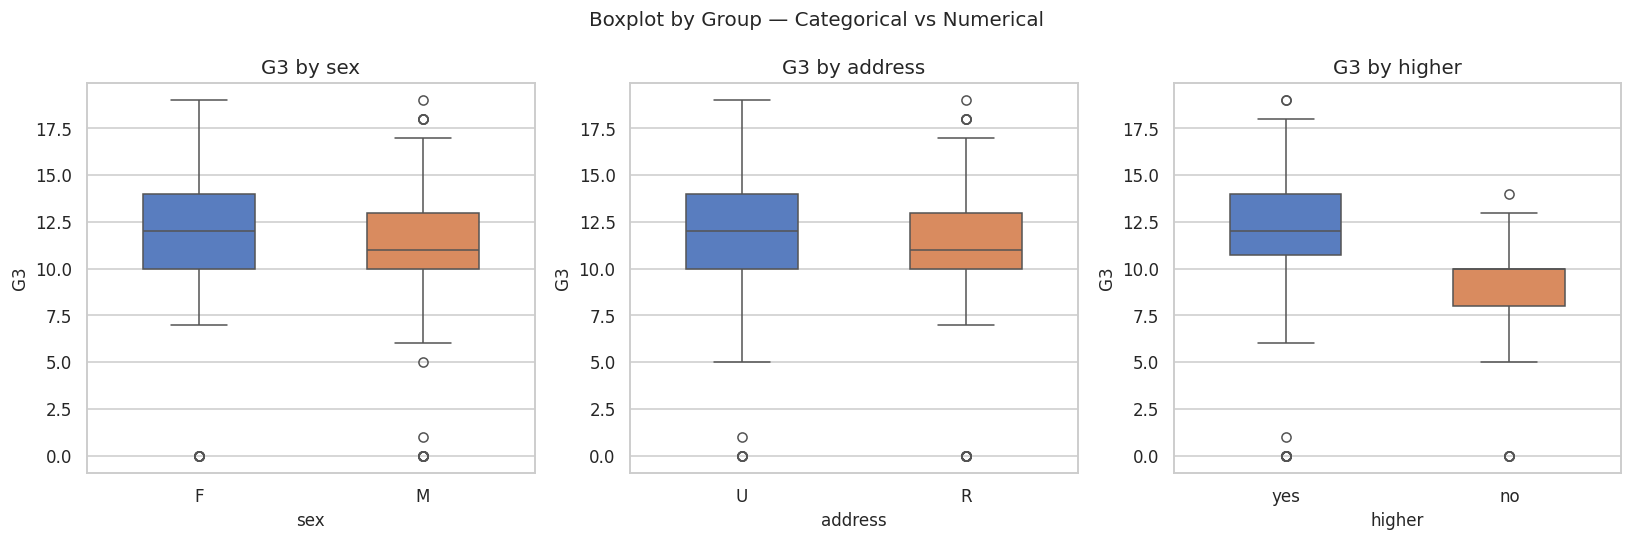

'higher' (wants higher education) shows the most visible difference in G3 distribution.


In [17]:
# ── 6.1  Boxplot by group ─────────────────────────────────────────────
# How does G3 vary across different student types?

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, cat in zip(axes, ["sex", "address", "higher"]):
    sns.boxplot(data=df, x=cat, y="G3", ax=ax,
                palette="muted", width=0.5)
    ax.set_title(f"G3 by {cat}")

plt.suptitle("Boxplot by Group — Categorical vs Numerical", fontsize=13)
plt.tight_layout()
plt.show()

print("'higher' (wants higher education) shows the most visible difference in G3 distribution.")

/tmp/ipykernel_635/2030522501.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_means, x=cat, y="G3",
/tmp/ipykernel_635/2030522501.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_means, x=cat, y="G3",


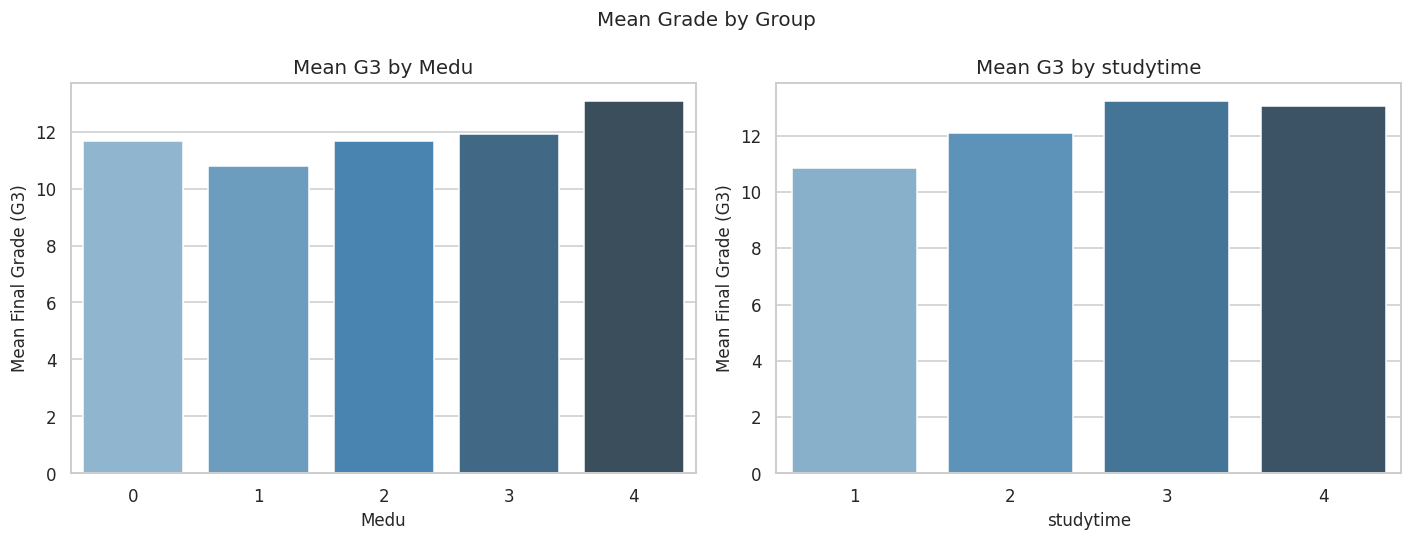

In [18]:
# ── 6.2  Bar chart of group means ────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cat in zip(axes, ["Medu", "studytime"]):
    group_means = df.groupby(cat)["G3"].mean().reset_index()
    sns.barplot(data=group_means, x=cat, y="G3",
                ax=ax, palette="Blues_d", edgecolor="white")
    ax.set_title(f"Mean G3 by {cat}")
    ax.set_ylabel("Mean Final Grade (G3)")

plt.suptitle("Mean Grade by Group", fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_635/243523533.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Medu", y="G3",


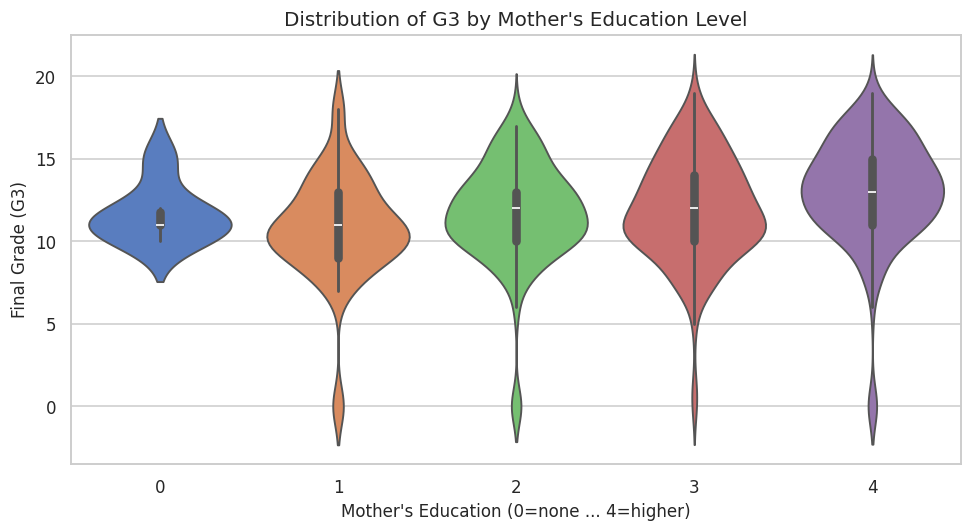

Higher Medu → wider top of the violin → more students achieving high grades.


In [19]:
# ── 6.3  Violin by group — richer than boxplot ────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))

sns.violinplot(data=df, x="Medu", y="G3",
               palette="muted", inner="box", ax=ax)
ax.set_title("Distribution of G3 by Mother's Education Level")
ax.set_xlabel("Mother's Education (0=none ... 4=higher)")
ax.set_ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()

print("Higher Medu → wider top of the violin → more students achieving high grades.")

---
## Part 7 — Full Bivariate Profile: Putting It All Together

  Bivariate Profile: G1  vs  G3
  n observations   : 649
  Pearson  r       : 0.8264  (p = 0.0000)
  Spearman ρ       : 0.8833  (p = 0.0000)
  Significance     : Significant at α=0.05



/tmp/ipykernel_635/112359773.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pair, x=f"{x_col}_q", y=y_col,


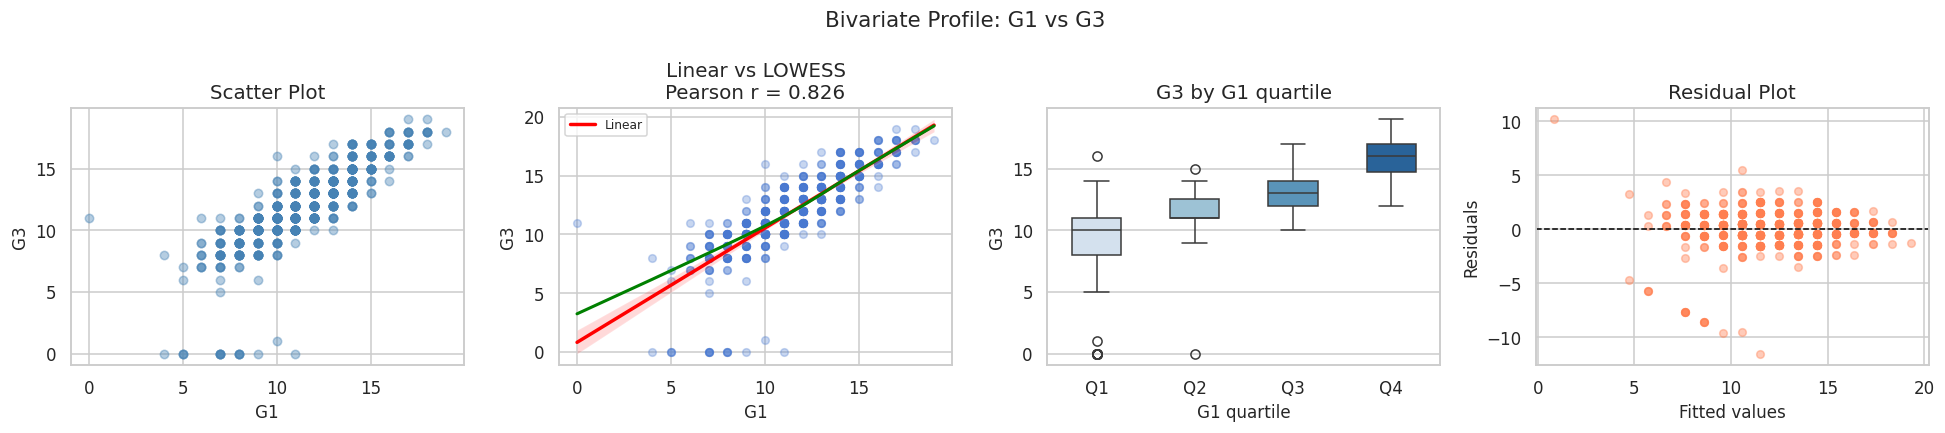

In [20]:
# ── 7.1  Reusable bivariate profile function ──────────────────────────
# Pass any two numerical columns and get stats + 4 plots.

def bivariate_profile(dataframe, x_col, y_col):
    """Full bivariate diagnostic for two numerical columns."""

    pair = dataframe[[x_col, y_col]].dropna()
    r_p, p_p = stats.pearsonr(pair[x_col], pair[y_col])
    r_s, p_s = stats.spearmanr(pair[x_col], pair[y_col])

    print(f"{'='*55}")
    print(f"  Bivariate Profile: {x_col}  vs  {y_col}")
    print(f"{'='*55}")
    print(f"  n observations   : {len(pair)}")
    print(f"  Pearson  r       : {r_p:.4f}  (p = {p_p:.4f})")
    print(f"  Spearman ρ       : {r_s:.4f}  (p = {p_s:.4f})")
    sig = "Significant" if p_p < 0.05 else "Not significant"
    print(f"  Significance     : {sig} at α=0.05")
    print()

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f"Bivariate Profile: {x_col} vs {y_col}", fontsize=14)

    # Scatter
    axes[0].scatter(pair[x_col], pair[y_col],
                    alpha=0.4, s=30, color="steelblue")
    axes[0].set_title("Scatter Plot")
    axes[0].set_xlabel(x_col)
    axes[0].set_ylabel(y_col)

    # Scatter + linear
    sns.regplot(data=pair, x=x_col, y=y_col,
                scatter_kws={"alpha": 0.3, "s": 25},
                line_kws={"color": "red", "label": "Linear"},
                ax=axes[1])
    sns.regplot(data=pair, x=x_col, y=y_col,
                scatter=False, lowess=True,
                line_kws={"color": "green", "linewidth": 2,
                           "label": "LOWESS"},
                ax=axes[1])
    axes[1].legend(fontsize=8)
    axes[1].set_title(f"Linear vs LOWESS\nPearson r = {r_p:.3f}")

    # Boxplot of Y by quantile groups of X
    pair = pair.copy()
    pair[f"{x_col}_q"] = pd.qcut(pair[x_col], q=4,
                                  labels=["Q1","Q2","Q3","Q4"],
                                  duplicates="drop")
    sns.boxplot(data=pair, x=f"{x_col}_q", y=y_col,
                ax=axes[2], palette="Blues", width=0.5)
    axes[2].set_title(f"{y_col} by {x_col} quartile")
    axes[2].set_xlabel(f"{x_col} quartile")

    # Residuals
    slope, intercept, _, _, _ = stats.linregress(pair[x_col], pair[y_col])
    fitted    = slope * pair[x_col] + intercept
    residuals = pair[y_col] - fitted
    axes[3].scatter(fitted, residuals, alpha=0.4, s=25, color="coral")
    axes[3].axhline(0, color="black", linewidth=1, linestyle="--")
    axes[3].set_title("Residual Plot")
    axes[3].set_xlabel("Fitted values")
    axes[3].set_ylabel("Residuals")

    plt.tight_layout()
    plt.show()


bivariate_profile(df, "G1", "G3")

In [ ]:
# Try a weaker, noisier relationship
bivariate_profile(df, "absences", "G3")

### Exercise 5 — Final Challenge
Choose **any two numerical columns** from the dataset.
1. Call `bivariate_profile()` on your chosen pair.
2. State whether the relationship is linear, monotonic, or nonlinear.
3. State whether correlation is statistically significant.
4. Identify one possible confounder and explain why it might be driving the correlation.
```python
# Your code here
```

In [ ]:
# Your answer here


---
## Summary

| Concept | Key Takeaway |
|---|---|
| **Scatter plot** | First step — always visualise before computing |
| **Pearson r** | Measures linear association; sensitive to outliers |
| **Spearman ρ** | Measures monotonic association; robust to outliers and skew |
| **p-value** | Indicates whether the correlation is statistically significant |
| **Correlation ≠ Causation** | Always ask: is there a confounder Z? |
| **Nonlinearity** | Pearson r can be zero even for strong curved relationships |
| **Anscombe's Quartet** | Same r, completely different shapes — always plot! |
| **LOWESS** | Flexible smoother that reveals the true shape without assumptions |
| **Residual plot** | If residuals have a pattern, the linear model is wrong |

---
### Take-Home Assignment
Find a dataset from Kaggle or UCI with at least 5 numerical columns.  
For **three variable pairs** of your choice:
1. Plot the scatter + regression line + LOWESS
2. Compute Pearson r and Spearman ρ with p-values
3. For each pair, state: linear or not? significant or not? possible confounder?
4. Write a short paragraph (5–6 sentences) summarising your findings across all three pairs

**Bring your notebook to the next session.**

---
*Eötvös Loránd University (ELTE) · Faculty of Informatics · Introduction to Data Science*